# Feature Selection

**Goal:** Explore the relationships between the available features and the target variable, identify correlations and potential feature interactions, develop useful engineered features, and use model-based feature importance to identify a compact set of relevant features for the subsequent modeling stage.

**Workflow:**

0. Setup the work environment.
1. Analyze feature–target relationships.
2. Investigate feature–feature correlations and potential redundancies.
3. Develop and evaluate candidate engineered features.
4. Use model-based feature importance to identify the most relevant features.
5. Summarize the feature selection outcome and rationale for the final feature set.

## 0. Setup

### Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from xgboost import XGBClassifier

### Helper functions

These functions are used throughout the analysis to calculate mutual information and generate correlation heatmaps while handling missing values and categorical features consistently.

In [2]:
def safe_divide(num, den):
    """Elementwise division that returns NaN (not inf) when the denominator is 0."""
    return num / den.replace(0, np.nan)


def mutual_info_series(X, y, random_state=42):
    """Mutual information between each column of X and y.

    Binary/near-constant columns are treated as discrete; numeric NaNs are filled
    with the column median first, since mutual_info_classif can't handle NaN.
    Returns a Series sorted descending.
    """
    discrete_mask = (X.nunique(dropna=True) <= 2).values
    X_filled = X.fillna(X.median(numeric_only=True))
    scores = mutual_info_classif(X_filled, y, discrete_features=discrete_mask, random_state=random_state)
    return pd.Series(scores, index=X.columns).sort_values(ascending=False)


def plot_corr_heatmap(corr_matrix, title, cmap="coolwarm", figsize=(10, 8), annot=True):
    """Lower-triangle-only correlation heatmap (upper triangle masked as redundant)."""
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix, mask=mask, annot=annot, fmt=".2f", cmap=cmap,
        vmin=-1, vmax=1, center=0, square=True, linewidths=.5,
        cbar_kws={"shrink": .8}, annot_kws={"size": 8}
    )
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Data loading

In [3]:
DATA_DIR = "/kaggle/input/competitions/playground-series-s6e8"

df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_train = df_train.drop(columns="id")

# Target column first for readability when plotting the correlation matrix
df_train = df_train[["addicted_label"] + [col for col in df_train.columns if col != "addicted_label"]]

target = df_train["addicted_label"]

df_train


,addicted_label,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,1,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No
1,0,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No
2,0,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes
3,1,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN
4,1,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,1,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No
691365,1,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No
691366,1,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No
691367,1,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN


### Data preparation
One-hot encoding of categorical variables and ordinal encoding of `stress_level`

In [4]:
categorical_cols = ["gender", "stress_level", "academic_work_impact"]

# Fill missing values
df_train[categorical_cols] = df_train[categorical_cols].fillna("Missing")

# Create ordinal encoding BEFORE one-hot encoding
stress_map = {"Low": 0, "Medium": 1, "High": 2, "Missing": np.nan}
df_train["stress_level_ordinal"] = df_train["stress_level"].map(stress_map)

# One-hot encode categorical columns
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
).set_output(transform="pandas")

train_encoded = encoder.fit_transform(df_train[categorical_cols])

# Replace categorical columns with one-hot encoded columns
df_train = pd.concat(
    [
        df_train.drop(columns=categorical_cols),
        train_encoded
    ],
    axis=1
)

# Correlations
onehot_stress_cols = [
    c for c in df_train.columns
    if c.startswith("stress_level_")
    and c != "stress_level_ordinal"
]

print("One-hot dummy correlations with target:")
print(df_train[onehot_stress_cols].corrwith(target))

print("\nOrdinal encoding correlation with target:")
print(df_train["stress_level_ordinal"].corr(target))

One-hot dummy correlations with target:
stress_level_High       0.003029
stress_level_Low        0.002506
stress_level_Medium    -0.005426
stress_level_Missing   -0.000274
dtype: float64

Ordinal encoding correlation with target:
0.00034661457263194644


## 1. Analyze feature–target relationships

### Missingness vs target correlation

Is *whether* a value is missing itself informative? Computed here on the raw (pre-encoding) dataframe, before anything gets filled in.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


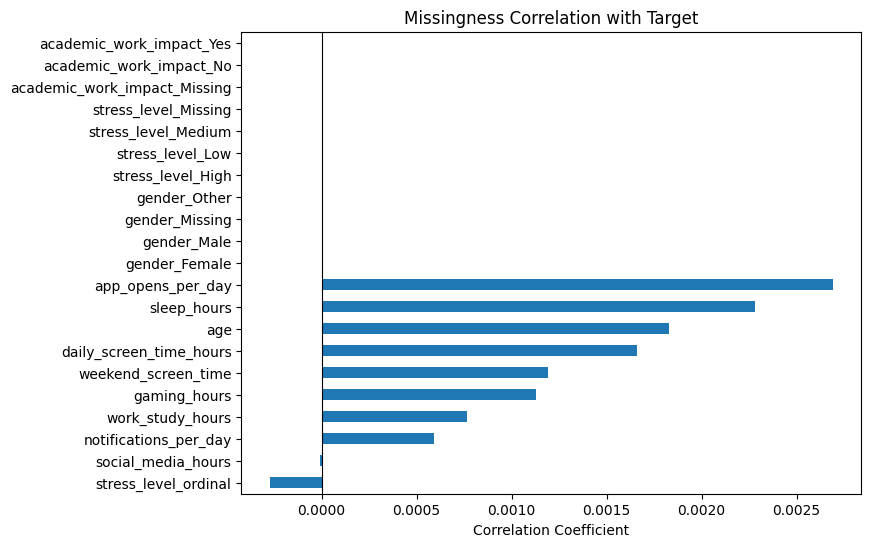

In [5]:
missing_flag_df = df_train.isnull().astype(int)
missing_corr = (
    missing_flag_df
    .corrwith(target)
    .drop("addicted_label", errors="ignore")
    .sort_values()
)

plt.figure(figsize=(8, 6))
missing_corr.plot(kind="barh")
plt.title("Missingness Correlation with Target")
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


No `_was_missing` flag showed a meaningful correlation with the target. None were carried into the final feature set.

### Feature correlation with target

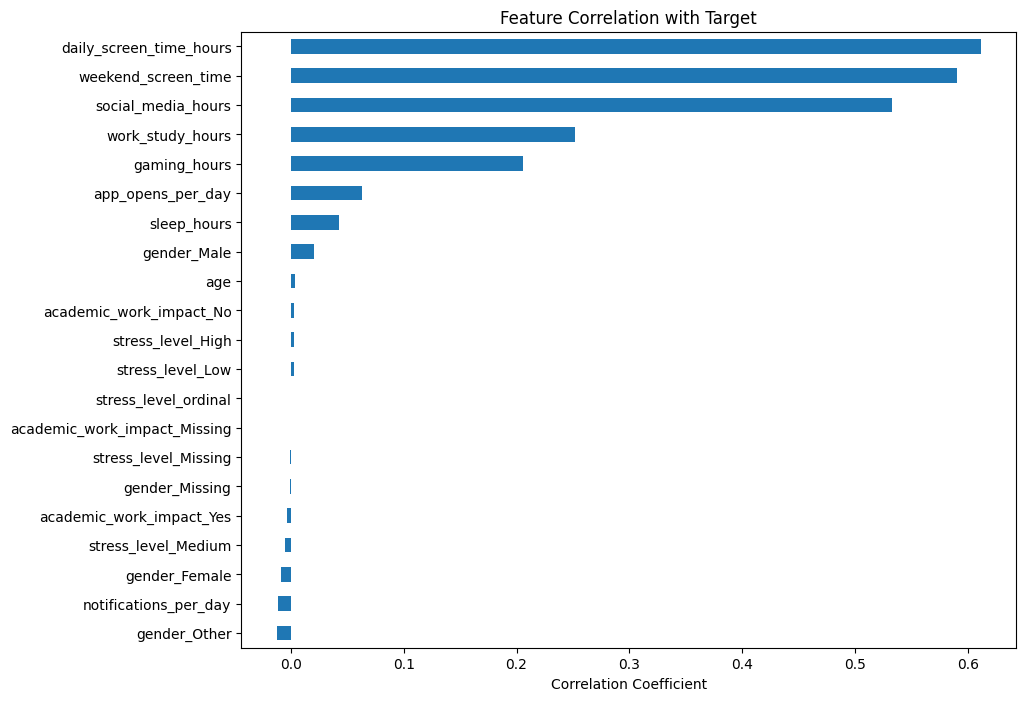

In [6]:
corr_matrix = df_train.corr()

target_corr = corr_matrix["addicted_label"].sort_values(ascending=True)

plt.figure(figsize=(10, 8))
# Drop 'addicted_label' from the plot so it doesn't show a 1.0 correlation with itself
target_corr.drop("addicted_label").plot(kind="barh")
plt.title("Feature Correlation with Target")
plt.xlabel("Correlation Coefficient")
plt.show()


### Mutual information with target

Correlation (Pearson/Spearman) only catches linear/monotonic relationships. Mutual information also picks up non-linear and non-monotonic dependence.

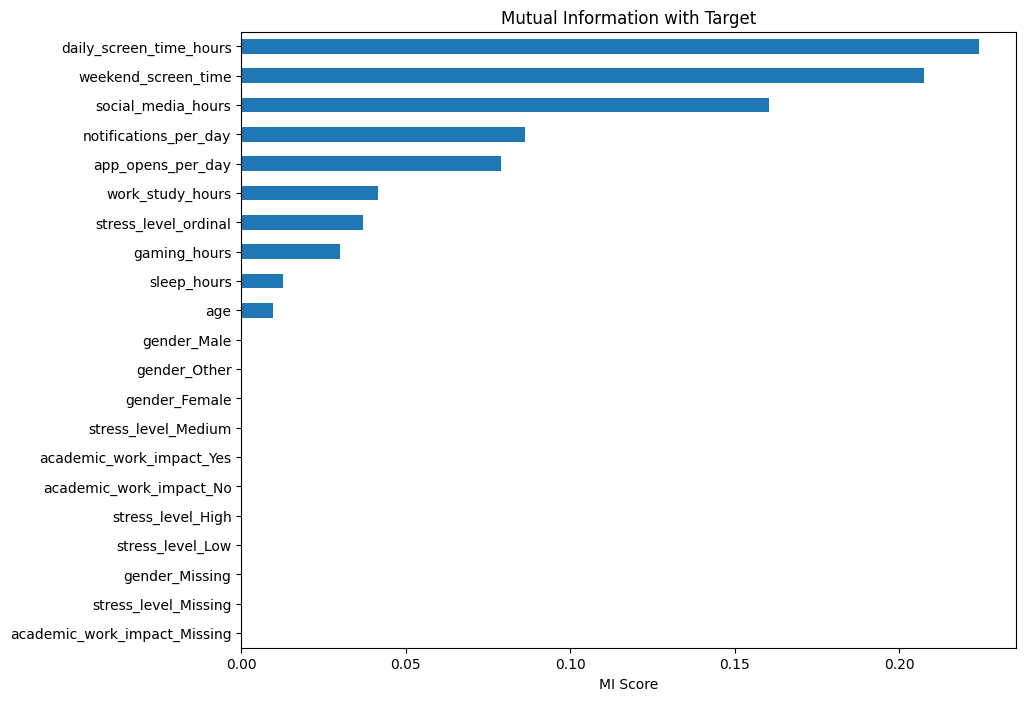

In [7]:
X_mi = df_train.drop(columns="addicted_label")
mi_series = mutual_info_series(X_mi, target)


plt.figure(figsize=(10, 8))
mi_series.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Mutual Information with Target")
plt.xlabel("MI Score")
plt.show()

### Pairwise feature ranking (AUC-based)

For every pair of features, fit a small model and see how much signal the pair carries jointly. 

Scored with a lightweight, untuned XGBoost + ROC AUC, since AUC is what the competition actually scores on and matches the point-biserial correlation and MI checks above.

In [8]:
def rank_feature_pairs(df, target_col="addicted_label"):
    """For every pair of features, fits a small XGBoost model and scores it with
    ROC AUC -- a quick screen for which feature pairs carry the most joint signal.
    """
    features = [col for col in df.columns if col != target_col]
    results = []

    for feat1, feat2 in combinations(features, 2):
        X = df[[feat1, feat2]]
        y = df[target_col]
        # Lightweight, untuned XGBoost: this is a screening tool run across every
        # pair (~C(n,2) fits), not the final model, so it deliberately isn't using
        # the full tuned hyperparameters (that would be far too slow here).
        model = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            objective="binary:logistic", random_state=42, verbosity=0,
            enable_categorical=True
        ).fit(X, y)
        auc = roc_auc_score(y, model.predict_proba(X)[:, 1])

        results.append({
            "Feature 1": feat1,
            "Feature 2": feat2,
            "Combined_AUC": auc
        })

    return pd.DataFrame(results).sort_values(by="Combined_AUC", ascending=False)


pair_rankings = rank_feature_pairs(df_train)
pair_rankings.head(10)


,Feature 1,Feature 2,Combined_AUC
20,daily_screen_time_hours,social_media_hours,0.913348
44,social_media_hours,weekend_screen_time,0.909995
26,daily_screen_time_hours,weekend_screen_time,0.895317
25,daily_screen_time_hours,app_opens_per_day,0.886628
22,daily_screen_time_hours,work_study_hours,0.886625
24,daily_screen_time_hours,notifications_per_day,0.885564
21,daily_screen_time_hours,gaming_hours,0.879726
106,notifications_per_day,weekend_screen_time,0.875526
119,app_opens_per_day,weekend_screen_time,0.875449
23,daily_screen_time_hours,sleep_hours,0.871920


## 2. Investigate feature–feature correlations

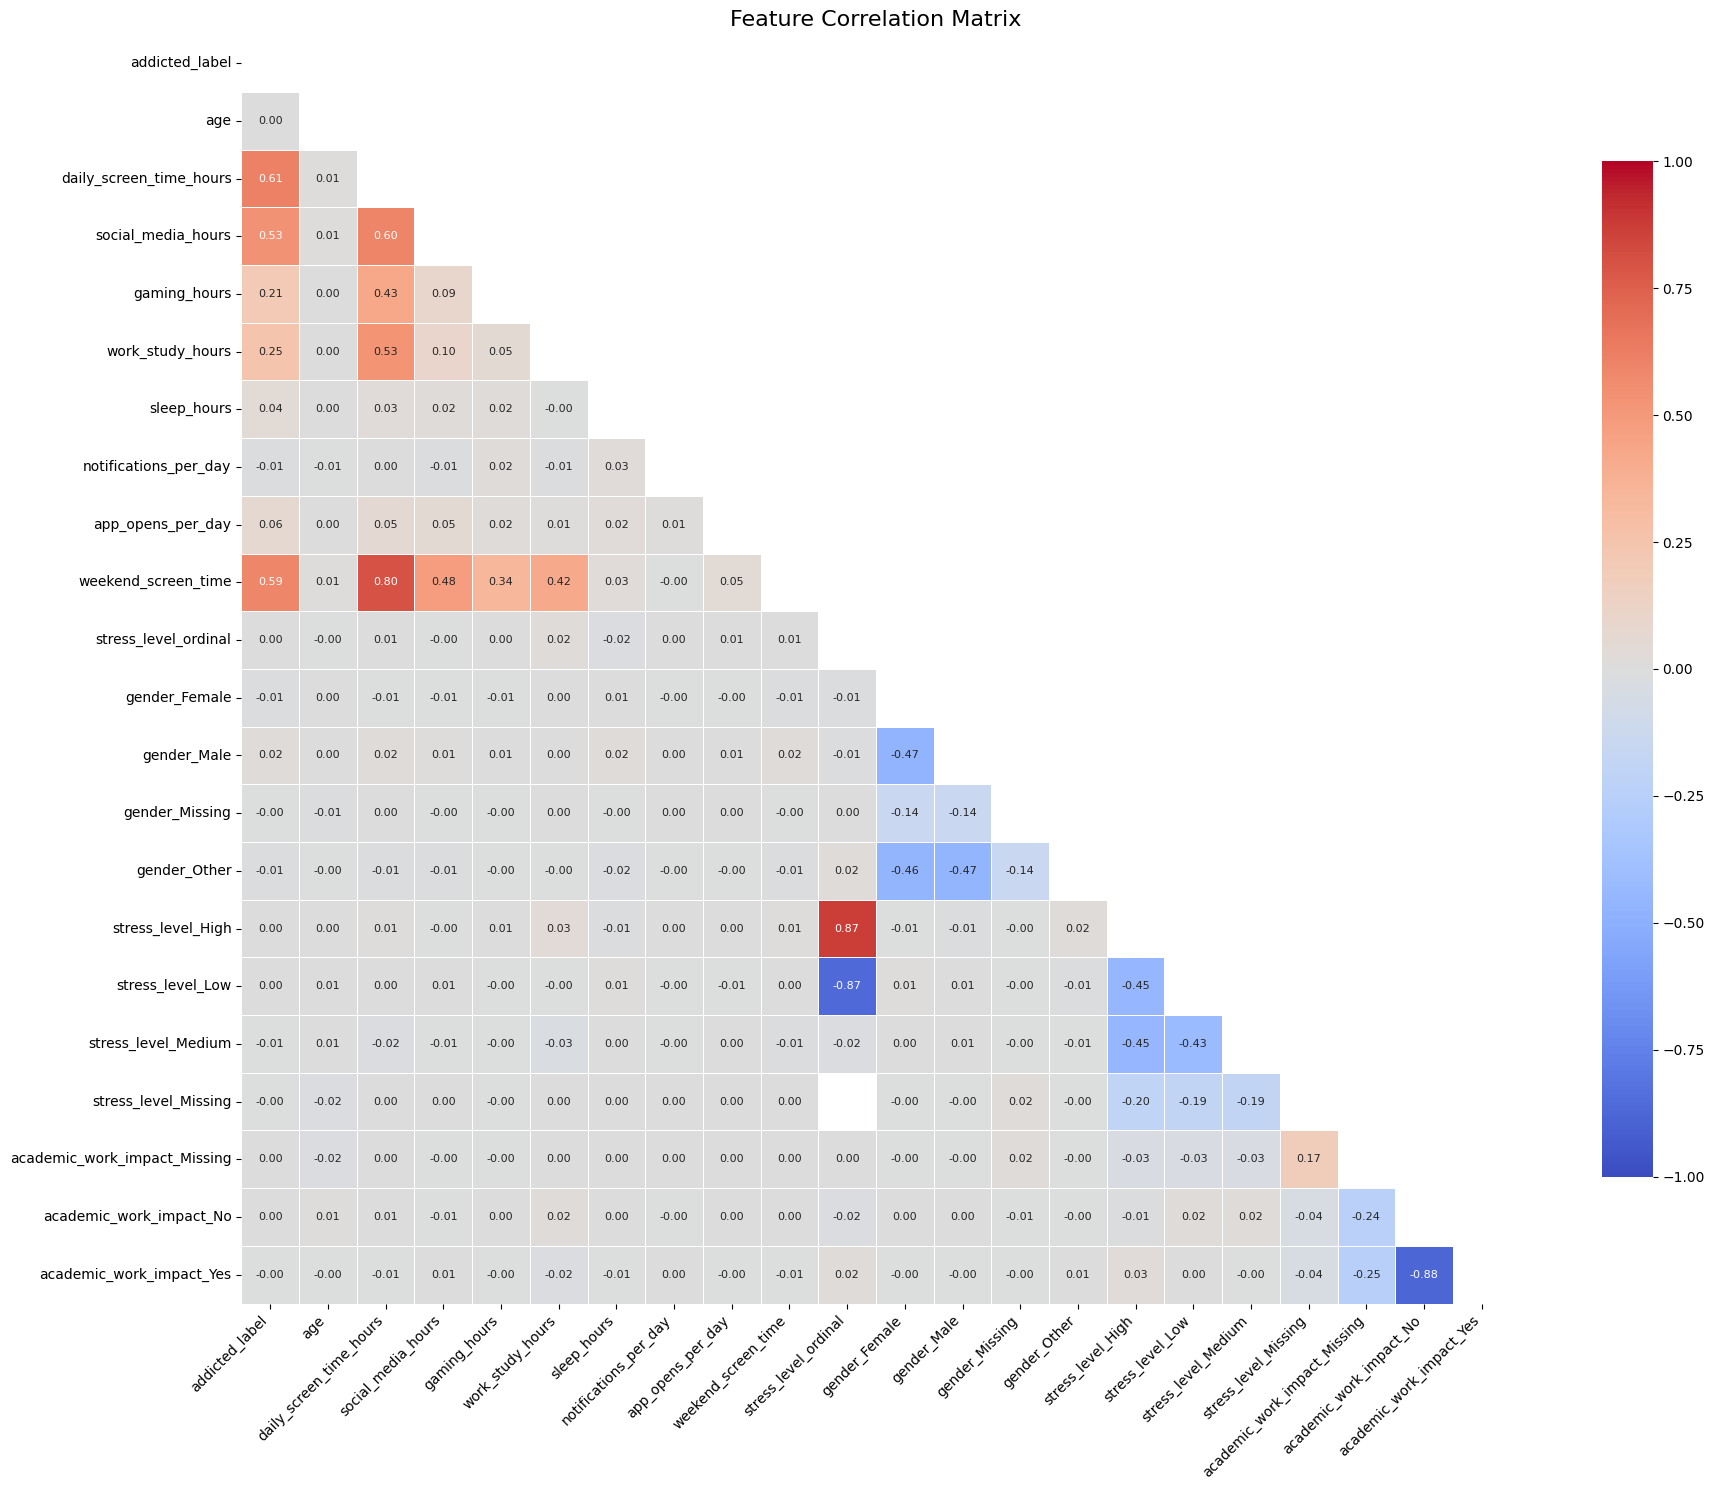

In [9]:
plot_corr_heatmap(corr_matrix, "Feature Correlation Matrix", figsize=(20, 15))


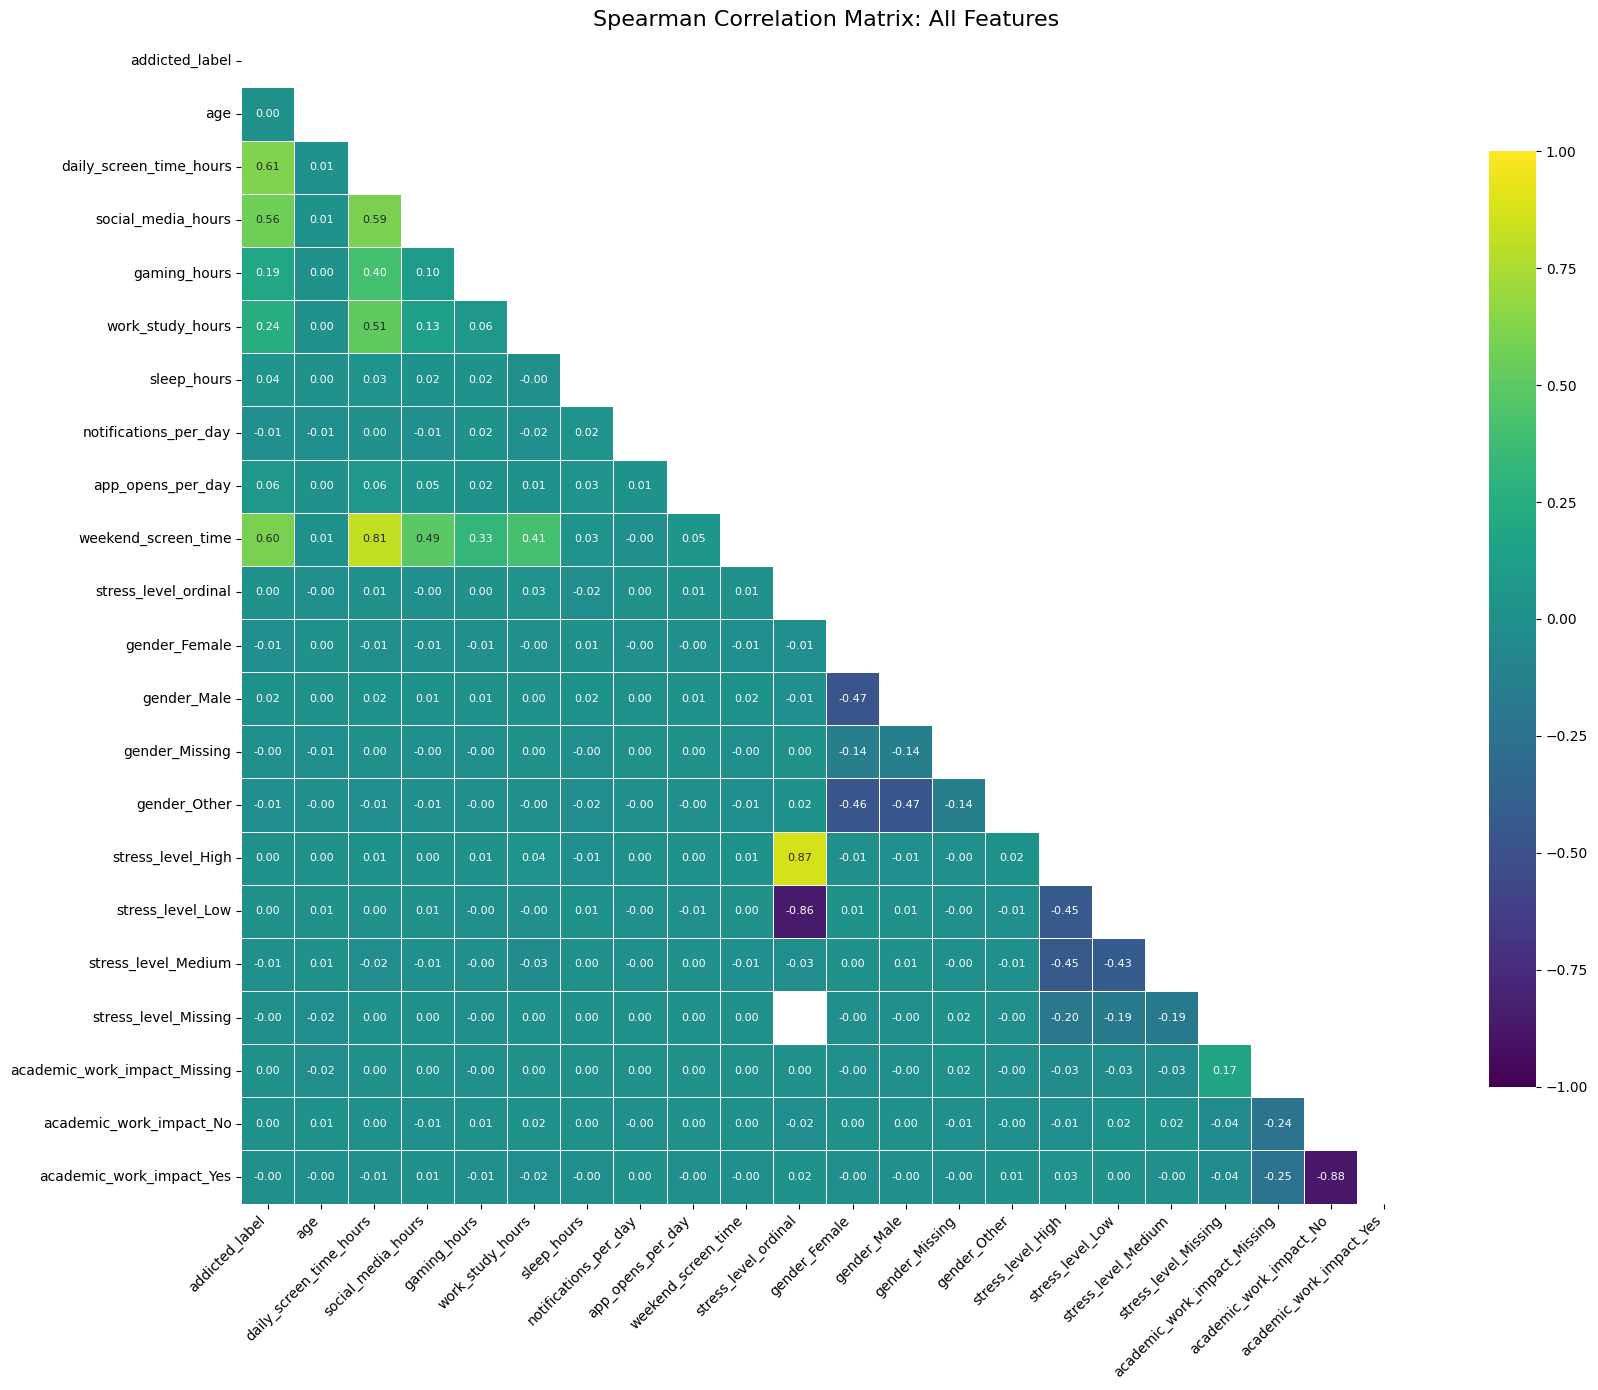

In [10]:
spearman_corr = df_train.corr(method="spearman")
plot_corr_heatmap(spearman_corr, "Spearman Correlation Matrix: All Features", cmap="viridis", figsize=(18, 14))


Both Pearson and Spearman show correlations between `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours`, and `weekend_screen_time`, suggesting these features capture related aspects of users' daily behavior and can be seen as a sort of behavioral cluster. The other significant negative correlations are mainly between one-hot encoded features, which is expected since categories within the same variable are mutually exclusive and therefore not particularly meaningful.

## 3. Engineered features

Several transformations were created to capture relative usage, differences between related variables, and combinations of existing features. Their relationship with the target was then compared using correlation and mutual information as the raw features.

In [11]:
# Relative usage
df_train["social_media_share"] = safe_divide(df_train["social_media_hours"], df_train["daily_screen_time_hours"])
df_train["gaming_share"] = safe_divide(df_train["gaming_hours"], df_train["daily_screen_time_hours"])
df_train["work_study_share"] = safe_divide(df_train["work_study_hours"], df_train["daily_screen_time_hours"])

# Differences
df_train["weekend_screen_diff"] = df_train["weekend_screen_time"] - df_train["daily_screen_time_hours"]
df_train["weekend_diff_abs"] = df_train["weekend_screen_diff"].abs()
df_train["free_time_hours"] = 24 - df_train["daily_screen_time_hours"] - df_train["sleep_hours"] - df_train["work_study_hours"]
df_train["unprompted_opens"] = (df_train["app_opens_per_day"] - df_train["notifications_per_day"]).clip(lower=0)

# Additional behavioral features
df_train["sleep_screen_ratio"] = safe_divide(df_train["sleep_hours"], df_train["daily_screen_time_hours"])
df_train["notif_per_open"] = safe_divide(df_train["notifications_per_day"], df_train["app_opens_per_day"])
df_train["leisure_bias"] = (df_train["social_media_share"] + df_train["gaming_share"] - df_train["work_study_share"])


# Bucket age into quartiles and one-hot encode
df_train["age_bucket"] = (
    pd.qcut(df_train["age"], q=4, duplicates="drop")
    .cat.add_categories("Missing")
    .fillna("Missing")
)

age_bucket_encoded = pd.get_dummies(
    df_train["age_bucket"],
    prefix="age_bucket",
    dtype=int
)

age_bucket_encoded.columns = [
    "age_bucket_missing" if col == "age_bucket_Missing"
    else f"age_bucket_q{i + 1}"
    for i, col in enumerate(age_bucket_encoded.columns)
]

df_train = pd.concat(
    [df_train.drop(columns="age_bucket"), age_bucket_encoded],
    axis=1
)

age_bucket_cols = age_bucket_encoded.columns.tolist()

### Behavioral segmentation via KMeans

The features `daily_screen_time_hours`, `social_media_hours`, `gaming_hours`, `work_study_hours` and `weekend_screen_time` showed correlations with each other in the previous feature-feature analysis, while also showing mutual information with the target. `notifications_per_day`, `app_opens_per_day` and `sleep_hours` also showed mutual information with the target.

Since these features appeared to contain useful information, K-Means was explored as a feature-engineering approach to combine them into a single behavioral representation. The idea was to see whether these variables could identify distinct user groups based on their usage and lifestyle patterns, and whether the resulting cluster assignment could provide a useful additional feature for the downstream classification task.

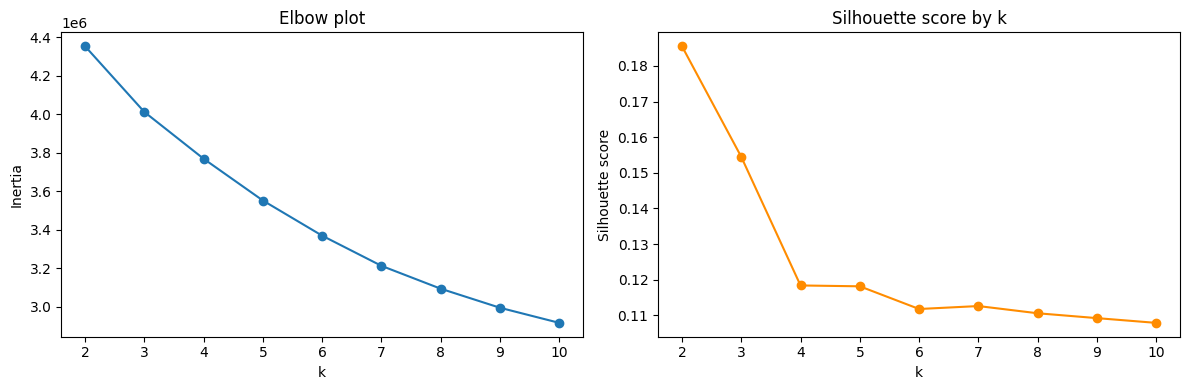

In [12]:
cluster_cols = [
    "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "weekend_screen_time", "sleep_hours",
    "notifications_per_day", "app_opens_per_day"
]

cluster_data = df_train[cluster_cols].fillna(df_train[cluster_cols].median())
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

k_range = range(2, 11)
inertias = []
silhouette_scores = []

# Silhouette on a subsample — computing it on the full ~691k rows for every k is
# expensive; a random subsample gives a good enough estimate
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(cluster_data_scaled), size=min(20000, len(cluster_data_scaled)), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_data_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(cluster_data_scaled[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow plot")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")

plt.tight_layout()
plt.show()


#### Choosing `n_clusters`

The clustering diagnostics showed weak cluster structure, with no clear elbow in inertia and a low silhouette score. Among the tested values, `k=2` achieved the highest silhouette score, so **2 clusters were selected** and the resulting feature was evaluated for its predictive value in the downstream model.

In [13]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_train["behavior_cluster"] = kmeans.fit_predict(cluster_data_scaled)

### Evaluating engineered features

In [14]:
engineered_cols = [
    "social_media_share", "gaming_share", "weekend_screen_diff",
    "notif_per_open", "sleep_screen_ratio", "free_time_hours",
    "work_study_share", "leisure_bias", "unprompted_opens",
    "weekend_diff_abs", "behavior_cluster",
] + age_bucket_cols

# Defensive no-op for the ratio columns above (safe_divide already returns NaN,
# not inf) -- kept in case a future feature here divides without safe_divide.
df_train[engineered_cols] = df_train[engineered_cols].replace([np.inf, -np.inf], np.nan)


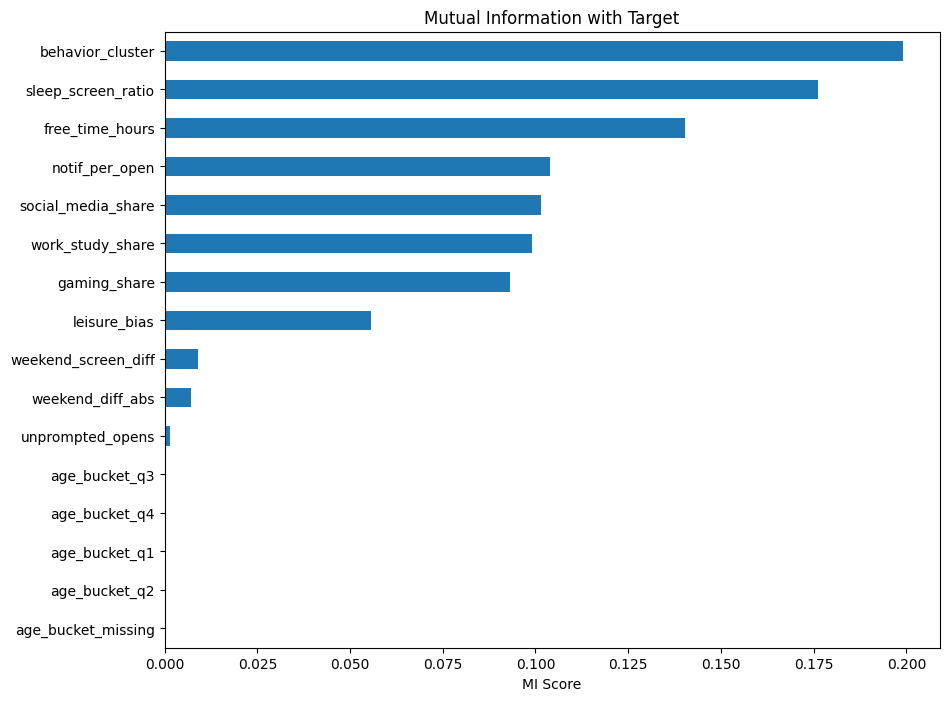

In [15]:
mi_engineered = mutual_info_series(df_train[engineered_cols], target)


plt.figure(figsize=(10, 8))
mi_engineered.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Mutual Information with Target")
plt.xlabel("MI Score")
plt.show()

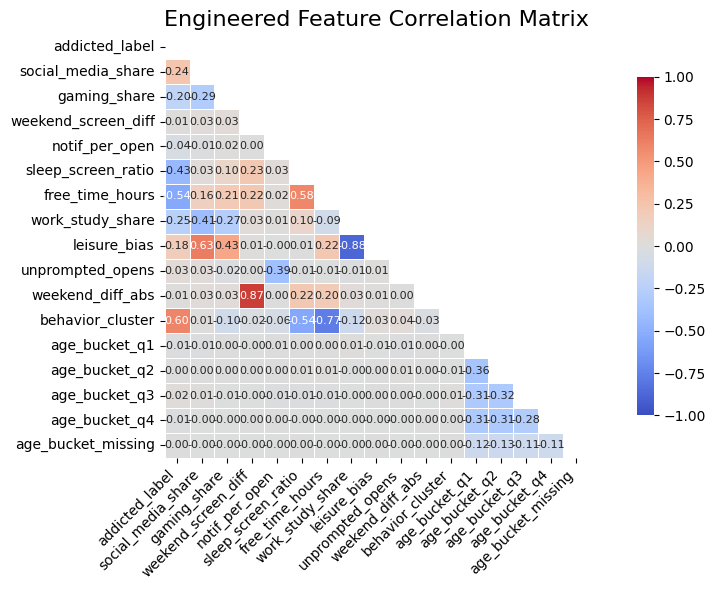

In [16]:
engineered_corr_matrix = df_train[["addicted_label"] + engineered_cols].corr()
plot_corr_heatmap(engineered_corr_matrix, "Engineered Feature Correlation Matrix", figsize=(10, 6))

## 4. Full-model feature importance

The previous analysis looked at features individually or in pairs. Here, permutation importance is used to evaluate the features in the context of a model trained on the full feature set.

The model is evaluated using ROC AUC, matching the competition metric. Features that cause a larger drop in AUC when permuted are considered more useful to the model. This also provides a different perspective from the correlation and mutual-information analyses, since the importance is based on the model's predictions rather than on a direct feature–target relationship.

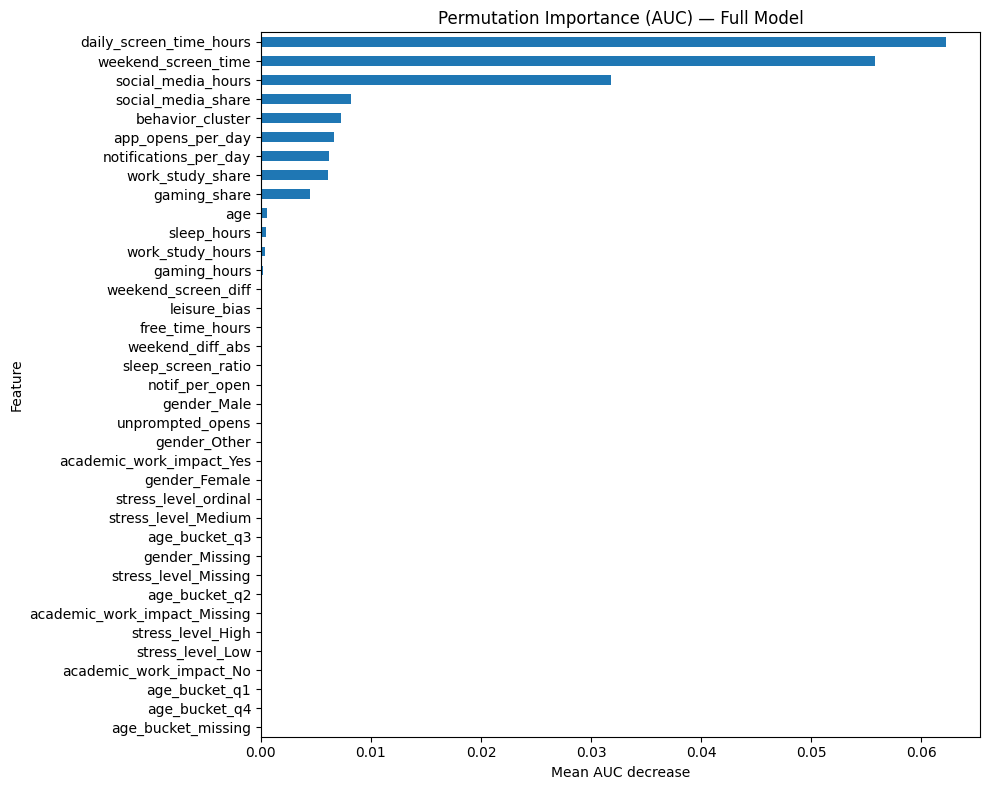

In [17]:
X_full = df_train.drop(columns="addicted_label").copy()

# Use the same model family as the final classifier so that the importance
# ranking is representative of the model family used later.
# A generic configuration is sufficient here; this is exploratory analysis,
# not the final tuned model.
full_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", random_state=42, verbosity=0,
    enable_categorical=True
).fit(X_full, target)

perm = permutation_importance(
    full_model, X_full, target,
    scoring="roc_auc", n_repeats=5, random_state=42, n_jobs=-1
)

perm_series = pd.Series(perm.importances_mean, index=X_full.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
perm_series.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Permutation Importance (AUC) — Full Model")
plt.xlabel("Mean AUC decrease")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 5. Summary: feature selection outcome

The table below summarizes the candidate features tested throughout the analysis and whether they were retained in the final feature set.

| Feature                                                                                                                                                                        | Used in final model? | Reason                                                                                                    |
| ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------- | --------------------------------------------------------------------------------------------------------- |
| `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`, `work_study_hours`, `sleep_hours`, `gaming_hours`, `app_opens_per_day`, `notifications_per_day`, `age` | ✅                    | Showed useful relationships with the target and/or ranked highly in the feature-importance analysis       |
| `social_media_share`, `gaming_share`, `work_study_share`, `leisure_bias`, `free_time_hours`, `weekend_screen_diff`                                                             | ✅                    | Engineered features that showed useful signal in the correlation, MI, and permutation-importance analyses |
| `behavior_cluster` (KMeans, `k=2`)                                                                                                                                             | ✅                    | Tested as a multivariate behavioral feature and retained based on its usefulness in the downstream model  |
| `gender`, `stress_level`, `academic_work_impact`                                                                                                                               | ❌                    | Provided little useful signal across the different analyses and encodings tested                          |
| `age_bucket`                                                                                                                                                                   | ❌                    | Did not provide additional information over the raw `age` feature                                         |
| `unprompted_opens`, `weekend_diff_abs`                                                                                                                                         | ❌                    | Provided some signal, but were less useful than other related features                                    |
| `notif_per_open`, `sleep_screen_ratio`                                                                                                                                         | ❌                    | Did not provide enough additional signal over the existing features                                       |
| All `*_was_missing` flags                                                                                                                                                      | ❌                    | Did not show meaningful signal with respect to the target                                                 |
